# Task 2 — Unemployment Analysis with Python
**CodeAlpha Data Science Internship**

**Objective:** Analyze unemployment rate data across Indian states, clean and explore it, investigate the impact of Covid-19, identify patterns/seasonal trends, and present insights useful for economic or social policy.

**Datasets:**
- `Unemployment_in_India.csv` — Region x Rural/Urban, monthly, **May 2019 – Jun 2020**
- `Unemployment_Rate_upto_11_2020.csv` — Region (with zone + lat/long), monthly, **Jan 2020 – Oct 2020**

Both datasets span the Covid-19 lockdown period in India (a nationwide lockdown began **25 March 2020**), making them well suited for before/during/after comparison.


## 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 2. Load & Clean the Data

In [12]:
df1 = pd.read_csv("Unemployment_in_India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Raw shapes:", df1.shape, df2.shape)

# Clean column names (stray leading/trailing spaces from the source files)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print()
print("File 1 columns:", list(df1.columns))
print("File 2 columns:", list(df2.columns))


Raw shapes: (768, 7) (267, 9)

File 1 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
File 2 columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [13]:
# File 1 has 28 completely blank rows -> drop them
df1 = df1.dropna(how="all").copy()

# Strip whitespace from every text column in both files
for d in (df1, df2):
    for c in d.select_dtypes(include="object").columns:
        d[c] = d[c].astype(str).str.strip()

# Parse dates
df1["Date"] = pd.to_datetime(df1["Date"], format="%d-%m-%Y")
df2["Date"] = pd.to_datetime(df2["Date"], format="%d-%m-%Y")

# Rename the zone column in file 2 for clarity, drop the duplicated lat/long-region pair we don't need
df2 = df2.rename(columns={"Region.1": "Zone"})

print("Cleaned shapes:", df1.shape, df2.shape)
print()
print("File 1 missing values:\n", df1.isnull().sum())
print()
print("File 2 missing values:\n", df2.isnull().sum())
print()
print("File 1 date range:", df1["Date"].min().date(), "to", df1["Date"].max().date())
print("File 2 date range:", df2["Date"].min().date(), "to", df2["Date"].max().date())


Cleaned shapes: (740, 7) (267, 9)

File 1 missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

File 2 missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Zone                                       0
longitude                                  0
latitude                                   0
dtype: int64

File 1 date range: 2019-05-31 to 2020-06-30
File 2 date range: 2020-01-31 to 2020-10-31


In [14]:
print(df1.head())
print()
print(df1.describe())


           Region       Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh 2019-05-31   Monthly                             3.65   
1  Andhra Pradesh 2019-06-30   Monthly                             3.05   
2  Andhra Pradesh 2019-07-31   Monthly                             3.75   
3  Andhra Pradesh 2019-08-31   Monthly                             3.32   
4  Andhra Pradesh 2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

                                Date  Estimated Unemployment Rate (%)  \
count                            740       

## 3. National Unemployment Trend (Rural vs Urban)

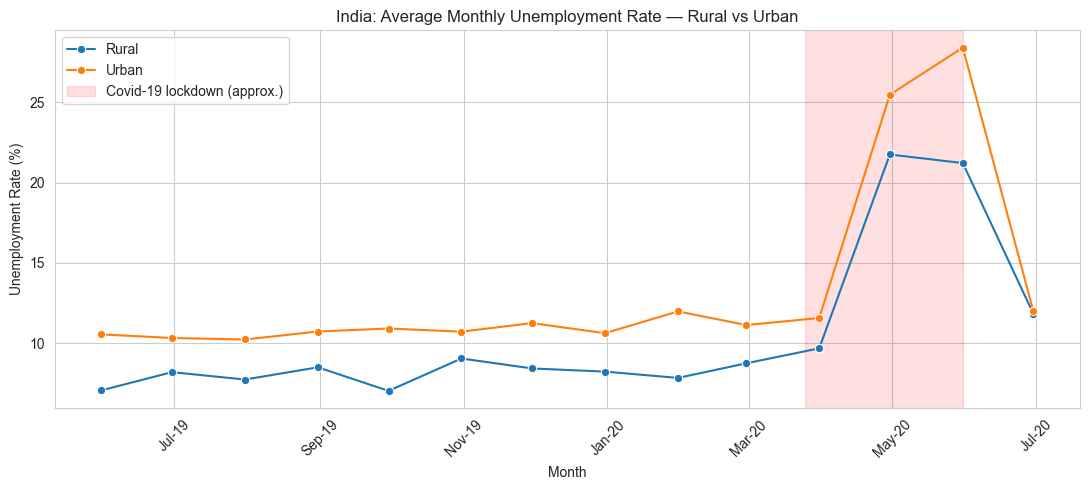

In [15]:
monthly_area = df1.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_area, x="Date", y="Estimated Unemployment Rate (%)", hue="Area", marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="red", alpha=0.12,
            label="Covid-19 lockdown (approx.)")
plt.title("India: Average Monthly Unemployment Rate — Rural vs Urban")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Month")
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Unemployment is broadly stable (roughly 6–9%) through 2019, then spikes sharply in **April 2020** — right after the nationwide lockdown began — before recovering through mid-2020. The spike is visible in both rural and urban areas, with **urban unemployment rising even higher**, consistent with cities being more dependent on in-person service/industrial jobs that were halted during lockdown.

                  Period  Avg Unemployment Rate (%)
Pre-Covid (Jan-Feb 2020)                   9.957736
   Covid Peak (Apr 2020)                  23.641569
    Post-Peak (Jun 2020)                  11.903600


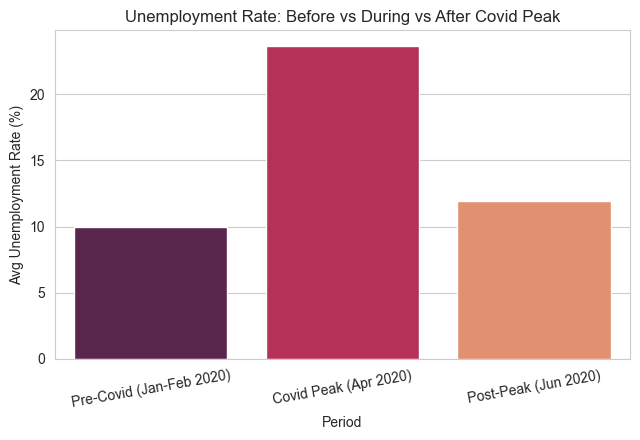


Unemployment rate jumped 13.7 percentage points (137% relative increase) at the Covid peak versus the pre-Covid baseline.


In [16]:
pre_covid = df1[df1["Date"].between("2020-01-01", "2020-02-29")]["Estimated Unemployment Rate (%)"].mean()
covid_peak = df1[df1["Date"].between("2020-04-01", "2020-04-30")]["Estimated Unemployment Rate (%)"].mean()
post_covid = df1[df1["Date"].between("2020-06-01", "2020-06-30")]["Estimated Unemployment Rate (%)"].mean()

comparison = pd.DataFrame({
    "Period": ["Pre-Covid (Jan-Feb 2020)", "Covid Peak (Apr 2020)", "Post-Peak (Jun 2020)"],
    "Avg Unemployment Rate (%)": [pre_covid, covid_peak, post_covid],
})
print(comparison.to_string(index=False))

plt.figure(figsize=(6.5, 4.5))
sns.barplot(data=comparison, x="Period", y="Avg Unemployment Rate (%)", hue="Period", palette="rocket", legend=False)
plt.title("Unemployment Rate: Before vs During vs After Covid Peak")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print(f"\nUnemployment rate jumped {covid_peak - pre_covid:.1f} percentage points "
      f"({(covid_peak/pre_covid - 1)*100:.0f}% relative increase) at the Covid peak versus the pre-Covid baseline.")


## 4. State-wise Analysis

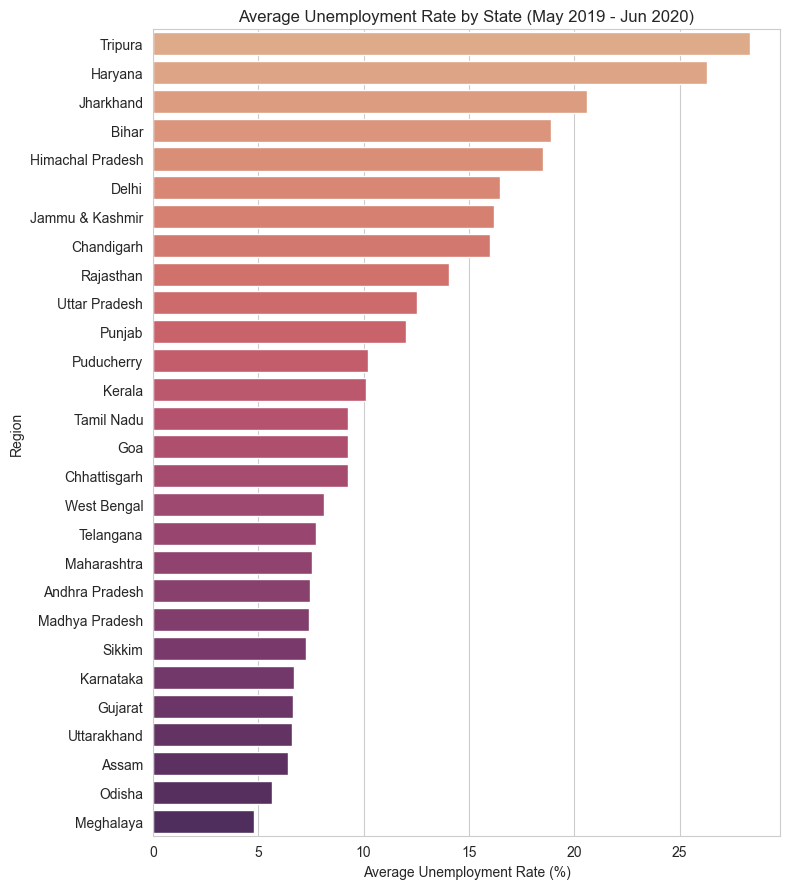

Top 5 highest average unemployment:
 Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64

Top 5 lowest average unemployment:
 Region
Gujarat        6.663929
Uttarakhand    6.582963
Assam          6.428077
Odisha         5.657857
Meghalaya      4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


In [17]:
state_avg = df1.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 9))
sns.barplot(x=state_avg.values, y=state_avg.index, hue=state_avg.index, palette="flare", legend=False)
plt.title("Average Unemployment Rate by State (May 2019 - Jun 2020)")
plt.xlabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

print("Top 5 highest average unemployment:\n", state_avg.head())
print()
print("Top 5 lowest average unemployment:\n", state_avg.tail())


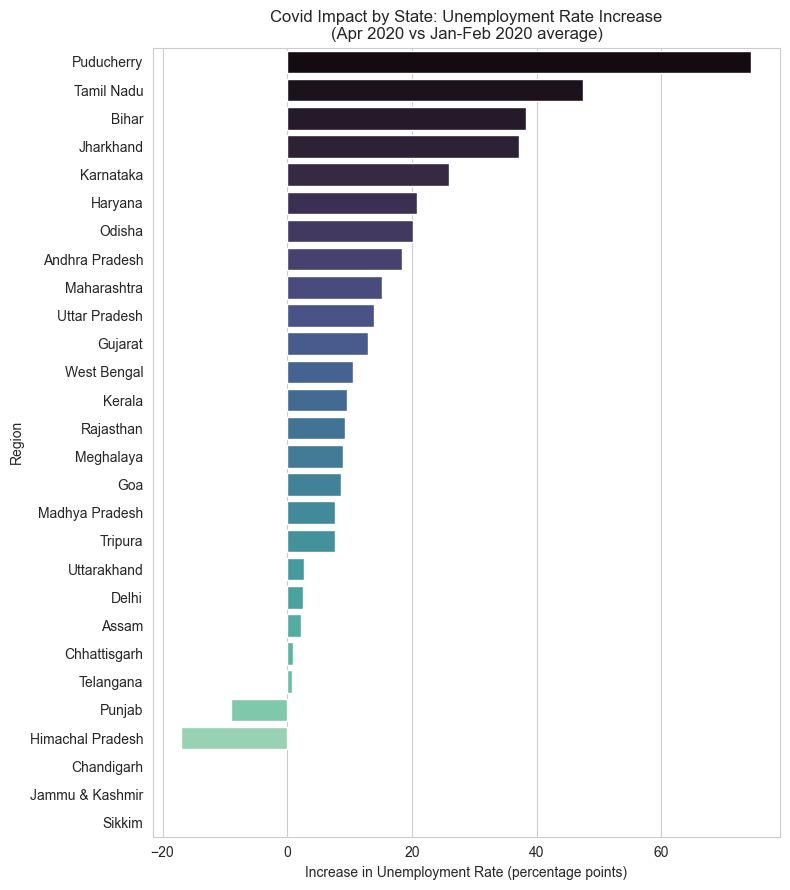

States hit hardest by the Covid lockdown spike:
 Region
Puducherry        74.4575
Tamil Nadu        47.4425
Bihar             38.2950
Jharkhand         37.1375
Karnataka         25.9275
Haryana           20.7675
Odisha            20.0925
Andhra Pradesh    18.4150
Name: Estimated Unemployment Rate (%), dtype: float64


In [18]:
state_covid_spike = (
    df1[df1["Date"] == "2020-04-30"].groupby("Region")["Estimated Unemployment Rate (%)"].mean()
    - df1[df1["Date"].between("2020-01-01", "2020-02-29")].groupby("Region")["Estimated Unemployment Rate (%)"].mean()
).sort_values(ascending=False)

plt.figure(figsize=(8, 9))
sns.barplot(x=state_covid_spike.values, y=state_covid_spike.index, hue=state_covid_spike.index,
            palette="mako", legend=False)
plt.title("Covid Impact by State: Unemployment Rate Increase\n(Apr 2020 vs Jan-Feb 2020 average)")
plt.xlabel("Increase in Unemployment Rate (percentage points)")
plt.tight_layout()
plt.show()

print("States hit hardest by the Covid lockdown spike:\n", state_covid_spike.head(8))


**Observation:** The size of the Covid-driven spike varies enormously by state — some states saw unemployment jump by 30+ percentage points in a single month, while others were far less affected, likely reflecting differences in local lockdown stringency and how dependent each state's economy is on sectors that could continue remotely (agriculture) versus those that could not (urban services, manufacturing, tourism).

## 5. Rural vs Urban Distribution

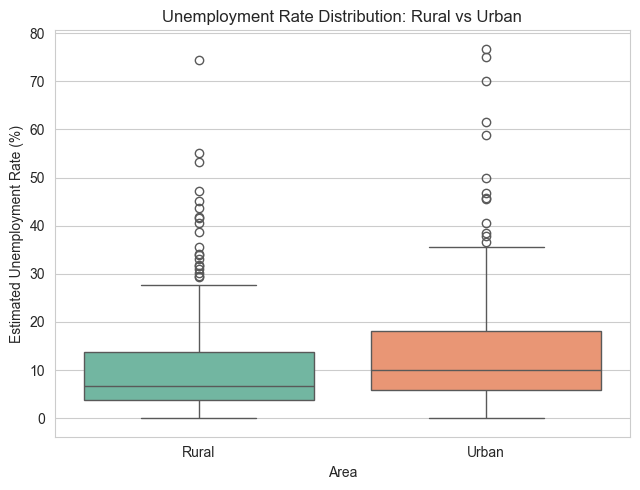

       count       mean        std  min   25%   50%     75%    max
Area                                                              
Rural  359.0  10.324791  10.038895  0.0  3.79  6.76  13.755  74.51
Urban  381.0  13.166614  11.165444  0.0  5.82  9.97  18.040  76.74


In [19]:
plt.figure(figsize=(6.5, 5))
sns.boxplot(data=df1, x="Area", y="Estimated Unemployment Rate (%)", hue="Area", palette="Set2", legend=False)
plt.title("Unemployment Rate Distribution: Rural vs Urban")
plt.tight_layout()
plt.show()

print(df1.groupby("Area")["Estimated Unemployment Rate (%)"].describe())


## 6. Zonal Analysis (using the second dataset, Jan–Oct 2020)

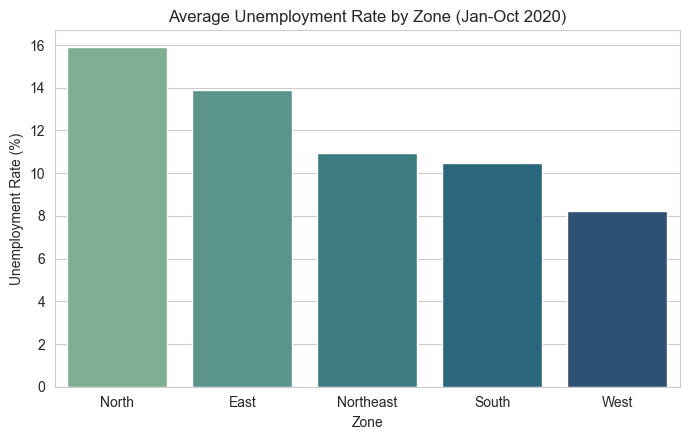

Zone
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64


In [20]:
zone_avg = df2.groupby("Zone")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=zone_avg.index, y=zone_avg.values, hue=zone_avg.index, palette="crest", legend=False)
plt.title("Average Unemployment Rate by Zone (Jan-Oct 2020)")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

print(zone_avg)


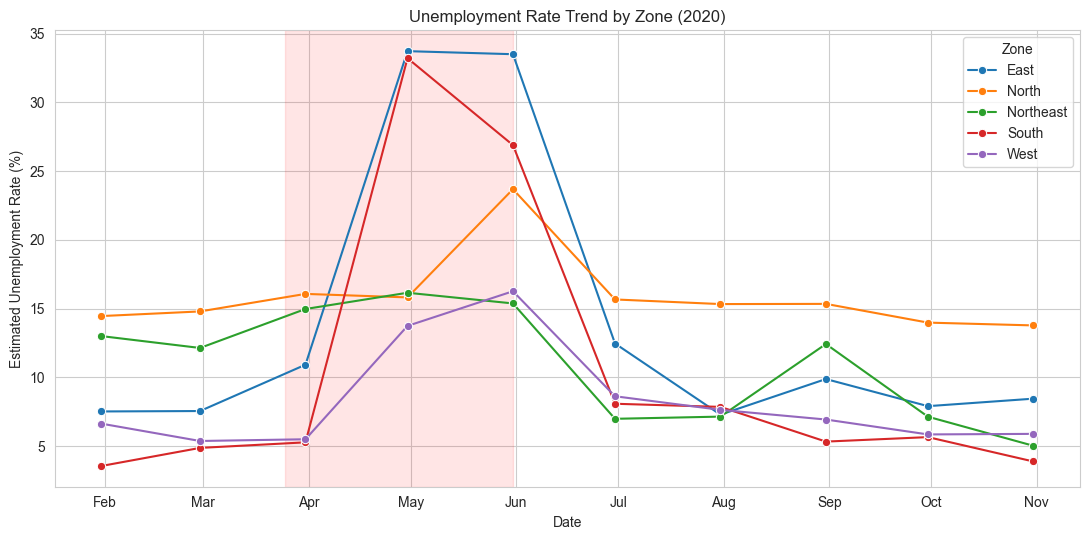

In [21]:
zone_monthly = df2.groupby(["Date", "Zone"])["Estimated Unemployment Rate (%)"].mean().reset_index()

plt.figure(figsize=(11, 5.5))
sns.lineplot(data=zone_monthly, x="Date", y="Estimated Unemployment Rate (%)", hue="Zone", marker="o")
plt.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-05-31"), color="red", alpha=0.10)
plt.title("Unemployment Rate Trend by Zone (2020)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.show()


**Observation:** Every zone experiences the same April 2020 spike, but the **South and West zones recover fastest** while other zones take longer to return to pre-Covid levels, suggesting regional differences in how quickly economic activity resumed after lockdown eased.

## 7. Relationship Between Labour Participation and Unemployment

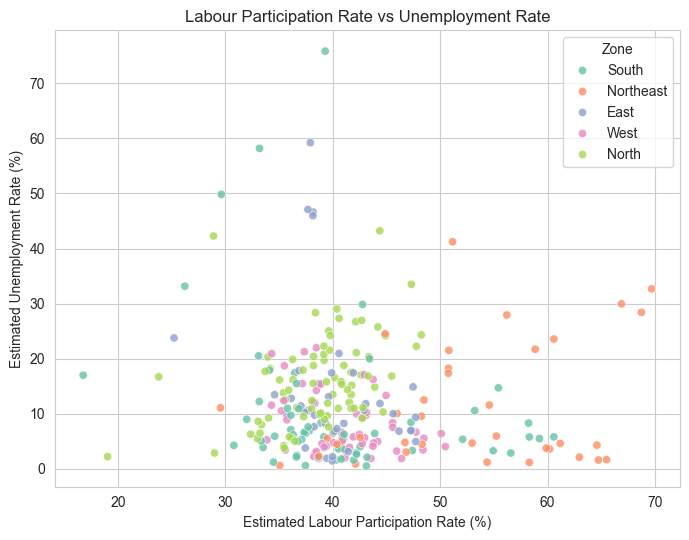

Correlation coefficient: -0.074


In [22]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df2, x="Estimated Labour Participation Rate (%)", y="Estimated Unemployment Rate (%)",
                 hue="Zone", palette="Set2", alpha=0.8)
plt.title("Labour Participation Rate vs Unemployment Rate")
plt.tight_layout()
plt.show()

corr = df2["Estimated Labour Participation Rate (%)"].corr(df2["Estimated Unemployment Rate (%)"])
print(f"Correlation coefficient: {corr:.3f}")


**Observation:** The weak/negative correlation suggests that higher labour-force participation does not by itself guarantee lower unemployment — areas can have both a large workforce actively seeking jobs *and* a high unemployment rate, which is a useful nuance for policymakers (boosting participation alone isn't sufficient; job creation matters just as much).

## 8. Key Insights & Policy-Relevant Takeaways

1. **Covid-19 caused an unprecedented, sudden shock**: national unemployment more than doubled (a ~137% relative increase) within a single month (April 2020) compared to the pre-Covid baseline, far larger than any pre-existing seasonal fluctuation in the data.
2. **Urban areas were hit harder** than rural areas during the lockdown spike, likely because urban jobs are more concentrated in sectors that cannot operate remotely (services, manufacturing, retail) versus agriculture-heavy rural economies.
3. **The impact was highly uneven across states** — some states saw unemployment increase by 30+ percentage points while others barely moved, pointing to differences in local lockdown stringency and sector composition. States with the largest spikes are the most useful targets for emergency employment support.
4. **Recovery speed also varied by zone** — South and West zones recovered faster than other zones by mid-2020, which could reflect differences in reopening policy or industry mix and is worth further investigation for targeted stimulus.
5. **Labour participation and unemployment are not simply inversely related**, so policies aimed purely at increasing workforce participation should be paired with active job-creation measures to actually reduce unemployment.

**Suggested next steps:** combine this with sector-level employment data (agriculture/industry/services) and state-level lockdown stringency indices to build a more causal picture of *why* some regions recovered faster than others.
